In [1]:
%cd ../..

/scratch/big/home/daawic/BSc-Thesis


In [3]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import transforms
from project.models import EDMCallum
from project.util.device import get_available_acc
from project.util.data import ReplayMemoryData
from project.util.metrics import PSNR, MSE

In [9]:
PATH = os.path.join("..", "checkpoints", "diff", "Breakout.pt")
DATA = os.path.join("..", "checkpoints", "memory", "Breakout.pt")

In [5]:
device = "cuda:5"

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize(0.5, 0.5),
])

In [7]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=500_000,
    train=False,
)

In [10]:
psnrs = []
psnrs = []

mses = []
mses = []

n = 64
x = torch.zeros((n, 4, 88, 88), device=device)

for i, img in enumerate(torch.randperm(10_000)[:n]):
    x[i] = data[img].to(device)

mask = torch.ones_like(x, device=device)
mask[:, :, :9] = 0

model = EDMCallum.from_checkpoint(PATH, device, U=1).to(device)

Us = range(1, 20)

for U in Us:

    model.set_U(U)

    with torch.no_grad():
        x_inpainted = model.inpaint(x, mask)
        psnrs.append(PSNR(x[:, :, :9].to("cpu"), x_inpainted[:, :, :9].to("cpu"), torch.tensor(2)))
        mses.append(MSE(x[:, :, :9].to("cpu"), x_inpainted[:, :, :9].to("cpu")))

100%|██████████| 32/32 [08:03<00:00, 15.12s/it]


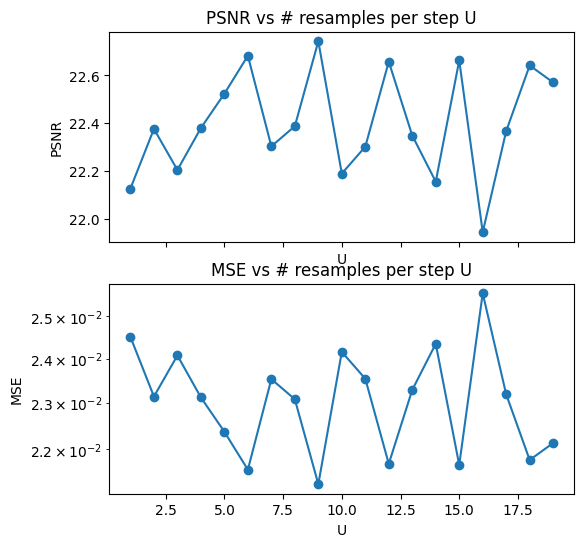

In [11]:
fig, axis = plt.subplots(2, figsize=(6, 6), sharex=True)

axis[0].plot(Us, psnrs, "o-")
axis[0].set_xlabel("U")
axis[0].set_ylabel("PSNR")
axis[0].set_title("PSNR vs # resamples per step U")

axis[1].semilogy(Us, mses, "o-")
axis[1].set_xlabel("U")
axis[1].set_ylabel("MSE")
axis[1].set_title("MSE vs # resamples per step U")

plt.show()